In [1]:
import sys
from pathlib import Path

print("Python executable:")
print(sys.executable)

PROJECT_DIR = Path.cwd().parent

print("\nProject directory:")
print(PROJECT_DIR)

print("\nProject exists:", PROJECT_DIR.exists())


Python executable:
c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\.venv\Scripts\python.exe

Project directory:
c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI

Project exists: True


In [2]:
from pathlib import Path

# Dataset paths
FAIRFACE_DIR = PROJECT_DIR / "data" / "demographic" / "FairFace"
UTKFACE_DIR = PROJECT_DIR / "data" / "age" / "UTKFace"
FER_DIR = PROJECT_DIR / "data" / "emotion"

print("FairFace :", FAIRFACE_DIR)
print("UTKFace  :", UTKFACE_DIR)
print("FER-2013 :", FER_DIR)

print("\nExistence check:")
print("FairFace :", FAIRFACE_DIR.exists())
print("UTKFace  :", UTKFACE_DIR.exists())
print("FER-2013 :", FER_DIR.exists())


FairFace : c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\data\demographic\FairFace
UTKFace  : c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\data\age\UTKFace
FER-2013 : c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\data\emotion

Existence check:
FairFace : True
UTKFace  : True
FER-2013 : True


In [3]:
# Count UTKFace images
utkface_count = len(list(UTKFACE_DIR.glob("*.jpg")))

# Count FER-2013 images
fer_count = len(list(FER_DIR.rglob("*.jpg")))

# Count FairFace Parquet files
fairface_parquet_count = len(list(FAIRFACE_DIR.rglob("*.parquet")))

print("Dataset file counts:")
print("--------------------")
print("UTKFace images       :", utkface_count)
print("FER-2013 images      :", fer_count)
print("FairFace Parquet     :", fairface_parquet_count)

Dataset file counts:
--------------------
UTKFace images       : 23708
FER-2013 images      : 35887
FairFace Parquet     : 8


In [4]:
from collections import Counter

emotion_counts = Counter()

for split in ["train", "test"]:
    split_dir = FER_DIR / split

    for emotion_dir in split_dir.iterdir():
        if emotion_dir.is_dir():
            count = len(list(emotion_dir.glob("*.jpg")))
            emotion_counts[emotion_dir.name] += count

print("FER-2013 class distribution:")
print("-----------------------------")

for emotion, count in sorted(emotion_counts.items()):
    print(f"{emotion:10s}: {count}")

print("-----------------------------")
print("Total images:", sum(emotion_counts.values()))

FER-2013 class distribution:
-----------------------------
angry     : 4953
disgust   : 547
fear      : 5121
happy     : 8989
neutral   : 6198
sad       : 6077
surprise  : 4002
-----------------------------
Total images: 35887


In [5]:
from collections import Counter

race_counts = Counter()
gender_counts = Counter()
age_values = []

for image_path in UTKFACE_DIR.glob("*.jpg"):
    parts = image_path.name.split("_")

    if len(parts) >= 4:
        age = int(parts[0])
        gender = int(parts[1])
        race = int(parts[2])

        age_values.append(age)
        gender_counts[gender] += 1
        race_counts[race] += 1

print("UTKFace race distribution:")
print("---------------------------")

for race, count in sorted(race_counts.items()):
    print(f"Race {race}: {count}")

print("\nUTKFace gender distribution:")
print("-----------------------------")

for gender, count in sorted(gender_counts.items()):
    print(f"Gender {gender}: {count}")

print("\nAge information:")
print("----------------")
print("Total:", len(age_values))
print("Minimum age:", min(age_values))
print("Maximum age:", max(age_values))

UTKFace race distribution:
---------------------------
Race 0: 10078
Race 1: 4526
Race 2: 3434
Race 3: 3975
Race 4: 1692

UTKFace gender distribution:
-----------------------------
Gender 0: 12391
Gender 1: 11314

Age information:
----------------
Total: 23705
Minimum age: 1
Maximum age: 116


In [6]:
import pandas as pd

fairface_files = sorted(FAIRFACE_DIR.rglob("*.parquet"))

print("FairFace Parquet files:")
print("-----------------------")

for file in fairface_files:
    print(file.relative_to(FAIRFACE_DIR))

print("\nTotal Parquet files:", len(fairface_files))

FairFace Parquet files:
-----------------------
0.25\train-00000-of-00002-d405faba4f4b9b85.parquet
0.25\train-00001-of-00002-dd3cb68164727418.parquet
0.25\validation-00000-of-00001-951dbd63c8724ee1.parquet
1.25\train-00000-of-00004-e715178553977907.parquet
1.25\train-00001-of-00004-f38b58e3987f3fbf.parquet
1.25\train-00002-of-00004-239e931aa9c3b3e6.parquet
1.25\train-00003-of-00004-847c279691a19548.parquet
1.25\validation-00000-of-00001-09e3e67bb00ab4ec.parquet

Total Parquet files: 8


In [7]:
# Inspect the first FairFace Parquet file

sample_file = fairface_files[0]

df_fairface = pd.read_parquet(sample_file)

print("File:")
print(sample_file)

print("\nColumns:")
print(df_fairface.columns.tolist())

print("\nShape:")
print(df_fairface.shape)

print("\nFirst 5 rows:")
display(df_fairface.head())

print("\nRace label distribution:")
print(df_fairface["race"].value_counts().sort_index())

File:
c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\data\demographic\FairFace\0.25\train-00000-of-00002-d405faba4f4b9b85.parquet

Columns:
['image', 'age', 'gender', 'race', 'service_test']

Shape:
(43372, 5)

First 5 rows:


,image,age,gender,race,service_test
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,6,0,0,True
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,4,1,1,False
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1,1,2,False
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3,1,1,True
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3,1,1,True



Race label distribution:
race
0    6075
1    6203
2    6200
3    8226
4    4612
5    6729
6    5327
Name: count, dtype: int64


In [8]:
# Compare FairFace 0.25 and 1.25 dataset versions

fairface_025 = sorted((FAIRFACE_DIR / "0.25").glob("*.parquet"))
fairface_125 = sorted((FAIRFACE_DIR / "1.25").glob("*.parquet"))

print("FairFace 0.25 files:", len(fairface_025))
print("FairFace 1.25 files:", len(fairface_125))

print("\n0.25 first file:")
df_025 = pd.read_parquet(fairface_025[0])
print("Shape:", df_025.shape)

print("\n1.25 first file:")
df_125 = pd.read_parquet(fairface_125[0])
print("Shape:", df_125.shape)

print("\nColumns:")
print(df_125.columns.tolist())

FairFace 0.25 files: 3
FairFace 1.25 files: 5

0.25 first file:
Shape: (43372, 5)

1.25 first file:
Shape: (21686, 5)

Columns:
['image', 'age', 'gender', 'race', 'service_test']


In [9]:
# Count total records in each FairFace version

def count_parquet_rows(files):
    total = 0

    for file in files:
        df = pd.read_parquet(file)
        total += len(df)

    return total


total_025 = count_parquet_rows(fairface_025)
total_125 = count_parquet_rows(fairface_125)

print("FairFace total records")
print("----------------------")
print("0.25:", total_025)
print("1.25:", total_125)

FairFace total records
----------------------
0.25: 97698
1.25: 97698


In [10]:
from PIL import Image
from io import BytesIO

# Read one FairFace image
sample_image_bytes = df_025.iloc[0]["image"]["bytes"]

sample_image = Image.open(BytesIO(sample_image_bytes))

print("Image format :", sample_image.format)
print("Image size   :", sample_image.size)
print("Image mode   :", sample_image.mode)

Image format : JPEG
Image size   : (224, 224)
Image mode   : RGB


In [11]:
FAIRFACE_RACE_MAP = {
    0: "East Asian",
    1: "Indian",
    2: "Black",
    3: "White",
    4: "Middle Eastern",
    5: "Latino/Hispanic",
    6: "Southeast Asian"
}

print("FairFace label mapping:")
print("-----------------------")

for label, name in FAIRFACE_RACE_MAP.items():
    print(f"{label} -> {name}")

FairFace label mapping:
-----------------------
0 -> East Asian
1 -> Indian
2 -> Black
3 -> White
4 -> Middle Eastern
5 -> Latino/Hispanic
6 -> Southeast Asian


In [12]:
# Create FairFace metadata from the 0.25 Parquet files

fairface_metadata = []

for parquet_file in fairface_025:
    df = pd.read_parquet(parquet_file)

    for _, row in df.iterrows():
        fairface_metadata.append({
            "age": row["age"],
            "gender": row["gender"],
            "race": row["race"],
            "race_name": FAIRFACE_RACE_MAP[int(row["race"])],
            "service_test": row["service_test"]
        })

fairface_metadata_df = pd.DataFrame(fairface_metadata)

print("FairFace metadata created.")
print("--------------------------")
print("Rows:", len(fairface_metadata_df))
print("Columns:", fairface_metadata_df.columns.tolist())

print("\nFirst 5 rows:")
display(fairface_metadata_df.head())

print("\nRace distribution:")
print(fairface_metadata_df["race_name"].value_counts())

FairFace metadata created.
--------------------------
Rows: 97698
Columns: ['age', 'gender', 'race', 'race_name', 'service_test']

First 5 rows:


,age,gender,race,race_name,service_test
0,6,0,0,East Asian,True
1,4,1,1,Indian,False
2,1,1,2,Black,False
3,3,1,1,Indian,True
4,3,1,1,Indian,True



Race distribution:
race_name
White              18612
Latino/Hispanic    14990
East Asian         13837
Indian             13835
Black              13789
Southeast Asian    12210
Middle Eastern     10425
Name: count, dtype: int64


In [13]:
# Save FairFace metadata

metadata_dir = PROJECT_DIR / "outputs" / "metadata"
metadata_dir.mkdir(parents=True, exist_ok=True)

fairface_metadata_path = metadata_dir / "fairface_metadata.csv"

fairface_metadata_df.to_csv(
    fairface_metadata_path,
    index=False
)

print("FairFace metadata saved successfully.")
print("Path:", fairface_metadata_path)
print("Exists:", fairface_metadata_path.exists())

FairFace metadata saved successfully.
Path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\outputs\metadata\fairface_metadata.csv
Exists: True


In [14]:
# Create UTKFace metadata

utkface_metadata = []

for image_path in UTKFACE_DIR.glob("*.jpg"):
    parts = image_path.name.split("_")

    if len(parts) >= 4:
        try:
            age = int(parts[0])
            gender = int(parts[1])
            race = int(parts[2])

            utkface_metadata.append({
                "image_path": str(image_path),
                "age": age,
                "gender": gender,
                "race": race
            })

        except ValueError:
            continue

utkface_metadata_df = pd.DataFrame(utkface_metadata)

print("UTKFace metadata created.")
print("-------------------------")
print("Rows:", len(utkface_metadata_df))
print("Columns:", utkface_metadata_df.columns.tolist())

print("\nFirst 5 rows:")
display(utkface_metadata_df.head())

print("\nAge statistics:")
print(utkface_metadata_df["age"].describe())

UTKFace metadata created.
-------------------------
Rows: 23705
Columns: ['image_path', 'age', 'gender', 'race']

First 5 rows:


,image_path,age,gender,race
0,c:\Users\hasibul shaikh\Documents\Nationality_...,100,0,0
1,c:\Users\hasibul shaikh\Documents\Nationality_...,100,0,0
2,c:\Users\hasibul shaikh\Documents\Nationality_...,100,1,0
3,c:\Users\hasibul shaikh\Documents\Nationality_...,100,1,0
4,c:\Users\hasibul shaikh\Documents\Nationality_...,100,1,0



Age statistics:
count    23705.000000
mean        33.300907
std         19.885708
min          1.000000
25%         23.000000
50%         29.000000
75%         45.000000
max        116.000000
Name: age, dtype: float64


In [15]:
# Save UTKFace metadata

utkface_metadata_path = metadata_dir / "utkface_metadata.csv"

utkface_metadata_df.to_csv(
    utkface_metadata_path,
    index=False
)

print("UTKFace metadata saved successfully.")
print("Path:", utkface_metadata_path)
print("Exists:", utkface_metadata_path.exists())

UTKFace metadata saved successfully.
Path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\outputs\metadata\utkface_metadata.csv
Exists: True


In [16]:
# Create FER-2013 metadata

emotion_map = {
    "angry": 0,
    "disgust": 1,
    "fear": 2,
    "happy": 3,
    "neutral": 4,
    "sad": 5,
    "surprise": 6
}

fer_metadata = []

for split in ["train", "test"]:
    split_dir = FER_DIR / split

    for emotion_dir in sorted(split_dir.iterdir()):
        if emotion_dir.is_dir() and emotion_dir.name in emotion_map:

            emotion_name = emotion_dir.name
            emotion_id = emotion_map[emotion_name]

            for image_path in emotion_dir.glob("*.jpg"):
                fer_metadata.append({
                    "image_path": str(image_path),
                    "emotion": emotion_name,
                    "emotion_id": emotion_id,
                    "split": split
                })

fer_metadata_df = pd.DataFrame(fer_metadata)

print("FER-2013 metadata created.")
print("--------------------------")
print("Rows:", len(fer_metadata_df))
print("Columns:", fer_metadata_df.columns.tolist())

print("\nFirst 5 rows:")
display(fer_metadata_df.head())

print("\nEmotion distribution:")
print(fer_metadata_df["emotion"].value_counts())

print("\nSplit distribution:")
print(fer_metadata_df["split"].value_counts())

FER-2013 metadata created.
--------------------------
Rows: 35887
Columns: ['image_path', 'emotion', 'emotion_id', 'split']

First 5 rows:


,image_path,emotion,emotion_id,split
0,c:\Users\hasibul shaikh\Documents\Nationality_...,angry,0,train
1,c:\Users\hasibul shaikh\Documents\Nationality_...,angry,0,train
2,c:\Users\hasibul shaikh\Documents\Nationality_...,angry,0,train
3,c:\Users\hasibul shaikh\Documents\Nationality_...,angry,0,train
4,c:\Users\hasibul shaikh\Documents\Nationality_...,angry,0,train



Emotion distribution:
emotion
happy       8989
neutral     6198
sad         6077
fear        5121
angry       4953
surprise    4002
disgust      547
Name: count, dtype: int64

Split distribution:
split
train    28709
test      7178
Name: count, dtype: int64


In [17]:
# Save FER-2013 metadata

fer_metadata_path = metadata_dir / "fer2013_metadata.csv"

fer_metadata_df.to_csv(
    fer_metadata_path,
    index=False
)

print("FER-2013 metadata saved successfully.")
print("Path:", fer_metadata_path)
print("Exists:", fer_metadata_path.exists())


FER-2013 metadata saved successfully.
Path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\outputs\metadata\fer2013_metadata.csv
Exists: True


In [18]:
# Final metadata verification

fairface_check = pd.read_csv(metadata_dir / "fairface_metadata.csv")
utkface_check = pd.read_csv(metadata_dir / "utkface_metadata.csv")
fer_check = pd.read_csv(metadata_dir / "fer2013_metadata.csv")

print("Metadata verification")
print("=====================")

print("FairFace :", len(fairface_check), "rows")
print("UTKFace  :", len(utkface_check), "rows")
print("FER-2013 :", len(fer_check), "rows")

print("\nExpected:")
print("FairFace : 97698")
print("UTKFace  : 23705")
print("FER-2013 : 35887")

print("\nVerification:")
print("FairFace :", len(fairface_check) == 97698)
print("UTKFace  :", len(utkface_check) == 23705)
print("FER-2013 :", len(fer_check) == 35887)

Metadata verification
FairFace : 97698 rows
UTKFace  : 23705 rows
FER-2013 : 35887 rows

Expected:
FairFace : 97698
UTKFace  : 23705
FER-2013 : 35887

Verification:
FairFace : True
UTKFace  : True
FER-2013 : True


In [19]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

print("\nAvailable GPUs:")
print(tf.config.list_physical_devices("GPU"))

print("\nAvailable CPUs:")
print(tf.config.list_physical_devices("CPU"))

TensorFlow version: 2.21.0

Available GPUs:
[]

Available CPUs:
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]


In [20]:
# Check FER-2013 image dimensions and channels

from PIL import Image

sample_emotion_image = fer_metadata_df.iloc[0]["image_path"]

img = Image.open(sample_emotion_image)

print("Sample image:")
print("Path   :", sample_emotion_image)
print("Format :", img.format)
print("Size   :", img.size)
print("Mode   :", img.mode)

Sample image:
Path   : c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\data\emotion\train\angry\Training_10118481.jpg
Format : JPEG
Size   : (48, 48)
Mode   : L


In [21]:
# Validate FER-2013 image files

valid_images = 0
invalid_images = 0

for image_path in fer_metadata_df["image_path"]:
    try:
        with Image.open(image_path) as img:
            img.verify()
        valid_images += 1
    except Exception:
        invalid_images += 1

print("FER-2013 image validation")
print("--------------------------")
print("Valid images  :", valid_images)
print("Invalid images:", invalid_images)
print("Total checked :", valid_images + invalid_images)

FER-2013 image validation
--------------------------
Valid images  : 35887
Invalid images: 0
Total checked : 35887


In [22]:
# Verify FER-2013 emotion labels

print("Emotion classes:")
print("----------------")

emotion_classes = sorted(fer_metadata_df["emotion"].unique())

for i, emotion in enumerate(emotion_classes):
    print(f"{i} -> {emotion}")

print("\nNumber of classes:", len(emotion_classes))

Emotion classes:
----------------
0 -> angry
1 -> disgust
2 -> fear
3 -> happy
4 -> neutral
5 -> sad
6 -> surprise

Number of classes: 7


In [23]:
import sys
from pathlib import Path
import tensorflow as tf
import numpy as np
import pandas as pd

print("Python:", sys.executable)
print("TensorFlow:", tf.__version__)

PROJECT_DIR = Path.cwd().parent

print("Project directory:", PROJECT_DIR)
print("Project exists:", PROJECT_DIR.exists())

Python: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\.venv\Scripts\python.exe
TensorFlow: 2.21.0
Project directory: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI
Project exists: True


In [24]:
# Load FER-2013 metadata

METADATA_DIR = PROJECT_DIR / "outputs" / "metadata"

FER_METADATA_PATH = METADATA_DIR / "fer2013_metadata.csv"

fer_df = pd.read_csv(FER_METADATA_PATH)

print("FER-2013 metadata loaded")
print("-------------------------")
print("Rows:", len(fer_df))
print("Columns:", fer_df.columns.tolist())

print("\nTrain images:", (fer_df["split"] == "train").sum())
print("Test images :", (fer_df["split"] == "test").sum())

print("\nEmotion classes:")
print(sorted(fer_df["emotion"].unique()))

FER-2013 metadata loaded
-------------------------
Rows: 35887
Columns: ['image_path', 'emotion', 'emotion_id', 'split']

Train images: 28709
Test images : 7178

Emotion classes:
['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [25]:
# Emotion class configuration

EMOTION_CLASSES = [
    "angry",
    "disgust",
    "fear",
    "happy",
    "neutral",
    "sad",
    "surprise"
]

NUM_CLASSES = len(EMOTION_CLASSES)

print("Emotion classes:")
for index, emotion in enumerate(EMOTION_CLASSES):
    print(f"{index} -> {emotion}")

print("\nNumber of classes:", NUM_CLASSES)

Emotion classes:
0 -> angry
1 -> disgust
2 -> fear
3 -> happy
4 -> neutral
5 -> sad
6 -> surprise

Number of classes: 7


In [26]:
# Check training class distribution

train_df = fer_df[fer_df["split"] == "train"].copy()

class_counts = (
    train_df["emotion_id"]
    .value_counts()
    .sort_index()
)

print("FER-2013 training class distribution")
print("------------------------------------")

for class_id, count in class_counts.items():
    print(f"{class_id} -> {EMOTION_CLASSES[class_id]:10s}: {count}")

print("\nTotal training images:", class_counts.sum())
print("Smallest class:", class_counts.min())
print("Largest class :", class_counts.max())

FER-2013 training class distribution
------------------------------------
0 -> angry     : 3995
1 -> disgust   : 436
2 -> fear      : 4097
3 -> happy     : 7215
4 -> neutral   : 4965
5 -> sad       : 4830
6 -> surprise  : 3171

Total training images: 28709
Smallest class: 436
Largest class : 7215


In [27]:
from sklearn.utils.class_weight import compute_class_weight

class_ids = np.arange(NUM_CLASSES)

class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=class_ids,
    y=train_df["emotion_id"].values
)

CLASS_WEIGHTS = {
    int(class_id): float(weight)
    for class_id, weight in zip(class_ids, class_weights_array)
}

print("Emotion class weights:")
print("----------------------")

for class_id, weight in CLASS_WEIGHTS.items():
    print(f"{class_id} -> {EMOTION_CLASSES[class_id]:10s}: {weight:.4f}")

Emotion class weights:
----------------------
0 -> angry     : 1.0266
1 -> disgust   : 9.4066
2 -> fear      : 1.0010
3 -> happy     : 0.5684
4 -> neutral   : 0.8260
5 -> sad       : 0.8491
6 -> surprise  : 1.2934


In [28]:
# Create TensorFlow datasets for FER-2013

FER_DIR = PROJECT_DIR / "data" / "emotion"

IMG_SIZE = (48, 48)
BATCH_SIZE = 64
SEED = 42

train_dir = FER_DIR / "train"
test_dir = FER_DIR / "test"

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels="inferred",
    label_mode="int",
    color_mode="grayscale",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("\nDataset created successfully.")
print("Training batches:", tf.data.experimental.cardinality(train_ds).numpy())
print("Testing batches :", tf.data.experimental.cardinality(test_ds).numpy())
print("Class names     :", train_ds.class_names)

Found 28709 files belonging to 7 classes.
Found 7178 files belonging to 7 classes.

Dataset created successfully.
Training batches: 449
Testing batches : 113
Class names     : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [29]:
# Optimize TensorFlow input pipeline

AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
test_ds = test_ds.prefetch(AUTOTUNE)

print("TensorFlow input pipeline optimized.")
print("Prefetch:", AUTOTUNE)


TensorFlow input pipeline optimized.
Prefetch: -1


In [30]:
# Inspect one training batch

for images, labels in train_ds.take(1):
    print("Image batch shape :", images.shape)
    print("Label batch shape :", labels.shape)
    print("Image data type   :", images.dtype)
    print("Minimum pixel     :", tf.reduce_min(images).numpy())
    print("Maximum pixel     :", tf.reduce_max(images).numpy())
    print("First 10 labels   :", labels[:10].numpy())
    break

Image batch shape : (64, 48, 48, 1)
Label batch shape : (64,)
Image data type   : <dtype: 'float32'>
Minimum pixel     : 0.0
Maximum pixel     : 255.0
First 10 labels   : [5 3 3 5 2 3 3 3 5 3]


In [31]:
# Define image normalization

normalization_layer = tf.keras.layers.Rescaling(
    1.0 / 255.0
)

print("Normalization layer created.")
print("Input range : 0–255")
print("Output range: 0–1")

Normalization layer created.
Input range : 0–255
Output range: 0–1


In [32]:
# Build the FER-2013 emotion CNN

model = tf.keras.Sequential([
    tf.keras.Input(shape=(48, 48, 1)),

    # Normalize pixels: 0–255 -> 0–1
    normalization_layer,

    # Block 1
    tf.keras.layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # Block 2
    tf.keras.layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.25),

    # Block 3
    tf.keras.layers.Conv2D(128, (3, 3), activation="relu", padding="same"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D((2, 2)),
    tf.keras.layers.Dropout(0.30),

    # Classification head
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.40),
    tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")
])

model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       589,952 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 684,423 (2.61 MB)

 Trainable params: 683,975 (2.61 MB)

 Non-trainable params: 448 (1.75 KB)

In [33]:
# Compile the emotion model

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Emotion model compiled successfully.")
print("Optimizer : Adam")
print("Learning rate: 0.001")
print("Loss      : Sparse Categorical Crossentropy")
print("Metric    : Accuracy")

Emotion model compiled successfully.
Optimizer : Adam
Learning rate: 0.001
Loss      : Sparse Categorical Crossentropy
Metric    : Accuracy


In [34]:
# Create training callbacks

MODEL_DIR = PROJECT_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

best_model_path = MODEL_DIR / "emotion_model_best.keras"

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(
        filepath=best_model_path,
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
        verbose=1
    ),

    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),

    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6,
        verbose=1
    )
]

print("Training callbacks created.")
print("Best model path:", best_model_path)

Training callbacks created.
Best model path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_best.keras


In [35]:
# Train the emotion detection model

EPOCHS = 30

history = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    class_weight=CLASS_WEIGHTS,
    callbacks=callbacks
)

Epoch 1/30


c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.0973 - loss: 1.9985
Epoch 1: val_accuracy improved from None to 0.24575, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_best.keras

Epoch 1: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_best.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 111s 241ms/step - accuracy: 0.0973 - loss: 1.9985 - val_accuracy: 0.2458 - val_loss: 3.1850 - learning_rate: 0.0010
Epoch 2/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 214ms/step - accuracy: 0.1103 - loss: 1.9479
Epoch 2: val_accuracy did not improve from 0.24575
449/449 ━━━━━━━━━━━━━━━━━━━━ 101s 225ms/step - accuracy: 0.1103 - loss: 1.9479 - val_accuracy: 0.1230 - val_loss: 1.9518 - learning_rate: 0.0010
Epoch 3/30
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 208ms/step - accuracy: 0.1025 - loss: 1.9461
Epoch 3: val_accuracy did not improve from 0.24575
449/449 ━━━━━━━━━━━━━━━━━━━━ 98s 218ms/step - accuracy: 0.1025 - loss

In [36]:
# Check predictions from the best saved emotion model

best_model = tf.keras.models.load_model(best_model_path)

print("Best model loaded successfully.")

for images, labels in test_ds.take(1):
    predictions = best_model.predict(images, verbose=0)
    predicted_classes = np.argmax(predictions, axis=1)

    print("Actual labels    :", labels.numpy()[:20])
    print("Predicted labels :", predicted_classes[:20])
    print("Prediction distribution:")
    print(np.bincount(predicted_classes, minlength=NUM_CLASSES))
    break

Best model loaded successfully.
Actual labels    : [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Predicted labels : [3 3 3 4 2 3 3 3 2 3 3 3 3 1 3 3 3 3 3 3]
Prediction distribution:
[ 0  2  5 53  4  0  0]


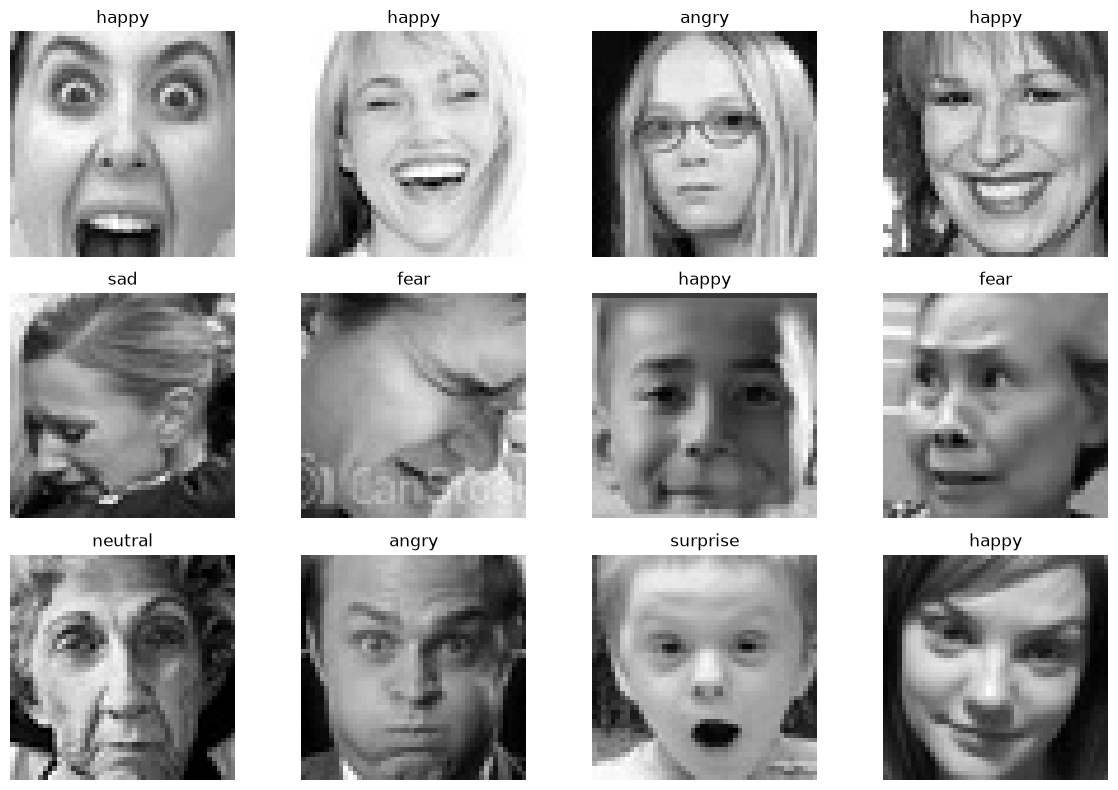

In [37]:
import matplotlib.pyplot as plt

# Display 12 training images with their labels

plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8").squeeze(), cmap="gray")
        plt.title(EMOTION_CLASSES[int(labels[i])])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [38]:
# Recompile the emotion model without class weights

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Emotion model recompiled.")
print("Optimizer     : Adam")
print("Learning rate : 0.0001")
print("Class weights : Disabled")
print("Loss          : Sparse Categorical Crossentropy")

Emotion model recompiled.
Optimizer     : Adam
Learning rate : 0.0001
Class weights : Disabled
Loss          : Sparse Categorical Crossentropy


In [39]:
# Train the corrected emotion model

EPOCHS = 20

history_v2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - accuracy: 0.1918 - loss: 1.9349
Epoch 1: val_accuracy improved from 0.24575 to 0.25355, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_best.keras

Epoch 1: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_best.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 108s 234ms/step - accuracy: 0.1918 - loss: 1.9349 - val_accuracy: 0.2536 - val_loss: 1.8580 - learning_rate: 1.0000e-04
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.2443 - loss: 1.8430
Epoch 2: val_accuracy improved from 0.25355 to 0.27473, saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_best.keras

Epoch 2: finished saving model to c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\models\emotion_model_best.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 100s 223ms/step - accuracy: 0.2443 - loss: 1.8430 - val_accuracy: 0.

In [40]:
# Evaluate the best emotion model

best_model = tf.keras.models.load_model(best_model_path)

test_loss, test_accuracy = best_model.evaluate(
    test_ds,
    verbose=1
)

print("\nFinal Emotion Model Evaluation")
print("--------------------------------")
print(f"Test Loss     : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")
print(f"Test Accuracy : {test_accuracy * 100:.2f}%")

113/113 ━━━━━━━━━━━━━━━━━━━━ 8s 57ms/step - accuracy: 0.5141 - loss: 1.2680

Final Emotion Model Evaluation
--------------------------------
Test Loss     : 1.2680
Test Accuracy : 0.5141
Test Accuracy : 51.41%


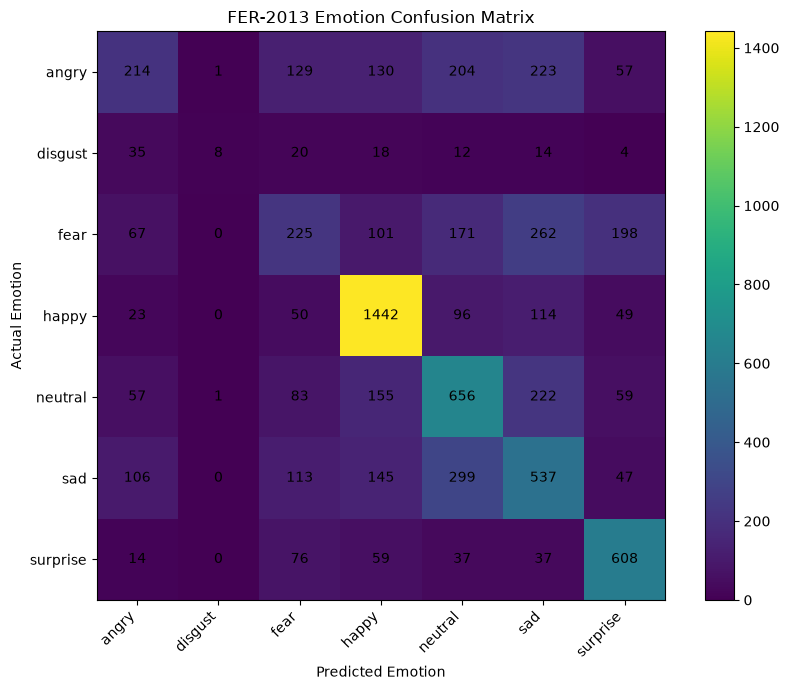


Classification Report
---------------------
              precision    recall  f1-score   support

       angry     0.4147    0.2234    0.2904       958
     disgust     0.8000    0.0721    0.1322       111
        fear     0.3233    0.2197    0.2616      1024
       happy     0.7034    0.8129    0.7542      1774
     neutral     0.4447    0.5320    0.4845      1233
         sad     0.3811    0.4306    0.4044      1247
    surprise     0.5949    0.7316    0.6562       831

    accuracy                         0.5141      7178
   macro avg     0.5232    0.4318    0.4262      7178
weighted avg     0.4992    0.5141    0.4940      7178



In [41]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import numpy as np

# Collect actual and predicted labels
y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = best_model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Confusion matrix
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=np.arange(NUM_CLASSES)
)

plt.figure(figsize=(9, 7))
plt.imshow(cm)

plt.title("FER-2013 Emotion Confusion Matrix")
plt.xlabel("Predicted Emotion")
plt.ylabel("Actual Emotion")

plt.xticks(
    np.arange(NUM_CLASSES),
    EMOTION_CLASSES,
    rotation=45,
    ha="right"
)

plt.yticks(
    np.arange(NUM_CLASSES),
    EMOTION_CLASSES
)

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

print("\nClassification Report")
print("---------------------")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=EMOTION_CLASSES,
        digits=4
    )
)

In [42]:
from pathlib import Path
from sklearn.metrics import classification_report

REPORT_DIR = PROJECT_DIR / "outputs" / "evaluation"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

report = classification_report(
    y_true,
    y_pred,
    target_names=EMOTION_CLASSES,
    digits=4
)

report_path = REPORT_DIR / "emotion_classification_report.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write("FER-2013 Emotion Model Evaluation\n")
    f.write("================================\n\n")
    f.write(f"Test Loss     : {test_loss:.4f}\n")
    f.write(f"Test Accuracy : {test_accuracy:.4f}\n")
    f.write(f"Test Accuracy : {test_accuracy * 100:.2f}%\n\n")
    f.write("Classification Report\n")
    f.write("---------------------\n")
    f.write(report)

print("Evaluation report saved successfully.")
print("Path:", report_path)

Evaluation report saved successfully.
Path: c:\Users\hasibul shaikh\Documents\Nationality_Detection_AI\outputs\evaluation\emotion_classification_report.txt
